In [23]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import os

In [8]:
load_dotenv()

True

In [9]:
model = ChatOpenAI(
    model = "openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens = 2000
)

In [10]:
class EvalSchema(BaseModel):
    feedback: str = Field(description='Detailed Feedback for the Essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

In [16]:
structured_model = model.with_structured_output(EvalSchema)

In [17]:
essay = """
LangGraph is a framework for building stateful, multi-agent AI applications 
using large language models (LLMs). Developed by **LangChain**, it extends 
traditional LLM workflows by representing them as graphs, where each node 
performs a specific task and edges define the flow of execution. Unlike linear 
chains, LangGraph supports conditional branching, loops, retries, and persistent 
memory, making it suitable for complex, real-world automation. Developers can 
integrate tools such as databases, APIs, web search, and retrieval systems 
(RAG) into graph nodes, enabling agents to reason, act, and collaborate 
effectively. It also provides state management, human-in-the-loop capabilities, 
and checkpointing for reliable execution. LangGraph is widely used to build 
intelligent assistants, customer support bots, research agents, coding assistants, 
and enterprise automation systems. Its modular architecture improves scalability, 
maintainability, and flexibility, making it a powerful framework for developing 
advanced agentic AI applications.
"""

In [18]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback assign a score out of 10 \n {essay}"

In [19]:
structured_model.invoke(prompt)

EvalSchema(feedback="The essay presents a clear and concise overview of the LangGraph framework. The language used is technical yet accessible, effectively communicating the features and advantages of the framework without overwhelming jargon. Sentences are generally well-structured, although a few sentences are somewhat complex and could benefit from simplification for broader understanding.\n\nStrengths:\n1. **Clarity**: The main ideas are presented clearly with logical progression.\n2. **Technical Detail**: It effectively incorporates necessary terminology relevant to the subject matter while remaining understandable to a knowledgeable audience.\n3. **Comprehensiveness**: The text covers essential functionalities and practical applications of LangGraph.\n4. **Professional Tone**: The essay maintains a professional and informative tone throughout.\n\nAreas for Improvement:\n1. **Sentence Variation**: Some sentences are long and may lose the reader's attention; employing more varied s

In [20]:
structured_model.invoke(prompt).feedback

'The essay presents a clear and concise explanation of the LangGraph framework, utilizing appropriate terminology related to artificial intelligence and large language models. The language is formal and technical, which fits the subject matter well. The structure is logical, guiding the reader from a general introduction to specific features and applications of LangGraph, ultimately making the information accessible and engaging for readers who may be familiar with the topic. However, the essay could benefit from breaking up longer sentences for better readability, and providing examples or case studies to illustrate the practical applications of LangGraph. Additionally, there are minor improvements that could be made in sentence variety to enhance the flow. Overall, the content is informative and well-tailored to an audience interested in AI frameworks, but some adjustments in sentence structure and additional elaboration could greatly enhance clarity and engagement.'

In [21]:
structured_model.invoke(prompt).score

9

In [22]:
import operator

In [24]:
class UPSCState(TypedDict):

    essay: str
    lang_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]

In [25]:
graph = StateGraph(UPSCState)

In [26]:
def evaluate_language(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the language quality of the following essay and provide a feedback assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'lang_feedback': output.feedback, 'individual_scores': [output.score]}


In [27]:
def evaluate_analysis(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}


In [28]:
def evaluate_thought(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}


In [30]:
def final_evaluation(state: UPSCState) -> UPSCState:
    prompt = f"Based on the given feedbacks, generate a summarized feedback \n language feedback - {state['lang_feedback']} \n Depth of analysis - {state['analysis_feedback']} \n Clarity of thought feedback - {state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content

    # avg cal
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [31]:
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('final_evaluation', final_evaluation)

In [35]:
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_thought')
graph.add_edge(START, 'evaluate_analysis')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')

graph.add_edge('final_evaluation', END)

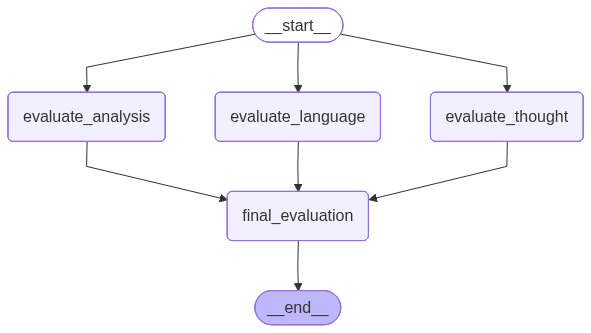

In [36]:
graph.compile()

In [37]:
workflow = graph.compile()

In [38]:
initial_state = {
    'essay': essay
}

workflow.invoke(initial_state)

{'essay': '\nLangGraph is a framework for building stateful, multi-agent AI applications \nusing large language models (LLMs). Developed by **LangChain**, it extends \ntraditional LLM workflows by representing them as graphs, where each node \nperforms a specific task and edges define the flow of execution. Unlike linear \nchains, LangGraph supports conditional branching, loops, retries, and persistent \nmemory, making it suitable for complex, real-world automation. Developers can \nintegrate tools such as databases, APIs, web search, and retrieval systems \n(RAG) into graph nodes, enabling agents to reason, act, and collaborate \neffectively. It also provides state management, human-in-the-loop capabilities, \nand checkpointing for reliable execution. LangGraph is widely used to build \nintelligent assistants, customer support bots, research agents, coding assistants, \nand enterprise automation systems. Its modular architecture improves scalability, \nmaintainability, and flexibility